# Task 3 — Forecast Future Market Trends

Generate a 12-month (252 trading day) forecast for TSLA using the best model from Task 2, with 95% confidence intervals, and interpret trend + uncertainty.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110

from src import data_loader, eda, arima_model, lstm_model, portfolio, backtest


In [2]:
raw = data_loader.fetch_asset_data(cache_dir='../data/raw')
cleaned = data_loader.clean_asset_data(raw)
prices = data_loader.combine_asset_data(cleaned, field='Adj Close')
tsla = prices['TSLA']
import json
order = tuple(json.load(open('../data/processed/arima_order.json'))['order'])
order

2026-07-04 07:46:40,514 [INFO] Loading cached data for TSLA from ../data/raw/TSLA.csv


2026-07-04 07:46:40,540 [INFO] Loading cached data for BND from ../data/raw/BND.csv


2026-07-04 07:46:40,556 [INFO] Loading cached data for SPY from ../data/raw/SPY.csv


2026-07-04 07:46:40,600 [INFO] TSLA: reindexed to 2997 business days, filled 109 missing trading days


2026-07-04 07:46:40,608 [INFO] BND: reindexed to 2997 business days, filled 109 missing trading days


2026-07-04 07:46:40,617 [INFO] SPY: reindexed to 2997 business days, filled 109 missing trading days


(0, 1, 0)

## 3.1 Fit on full history & forecast 12 months ahead

In [3]:
horizon = 252
full_fit = arima_model.fit_arima(tsla, order)
fc_mean, fc_lo, fc_hi = arima_model.forecast_arima(full_fit, steps=horizon)
future_dates = pd.bdate_range(start=tsla.index[-1] + pd.Timedelta(days=1), periods=horizon)
fc_mean.index = fc_lo.index = fc_hi.index = future_dates
fc_mean.tail()

2027-06-10    444.719447
2027-06-11    444.852025
2027-06-14    444.984604
2027-06-15    445.117182
2027-06-16    445.249760
Freq: B, Name: predicted_mean, dtype: float64

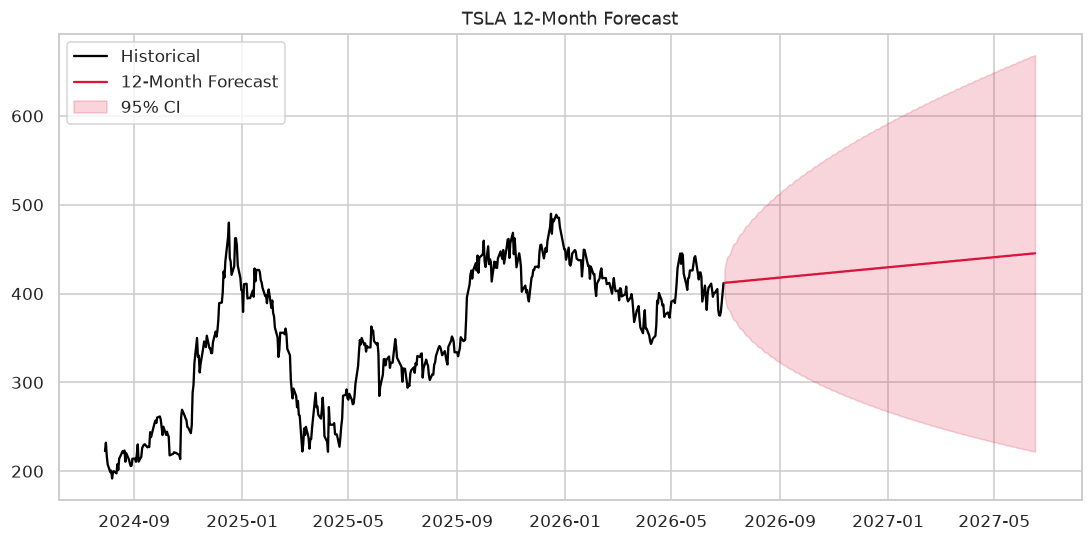

In [4]:
fig, ax = plt.subplots(figsize=(12,5.5))
ax.plot(tsla.index[-500:], tsla.values[-500:], label='Historical', color='black')
ax.plot(fc_mean.index, fc_mean.values, label='12-Month Forecast', color='crimson')
ax.fill_between(fc_mean.index, fc_lo, fc_hi, color='crimson', alpha=0.18, label='95% CI')
ax.legend(); ax.set_title('TSLA 12-Month Forecast'); plt.show()

## 3.2 Confidence interval widening over the horizon

As is expected for a differenced/random-walk-style model, the confidence interval widens over time, reflecting growing forecast uncertainty further into the future.

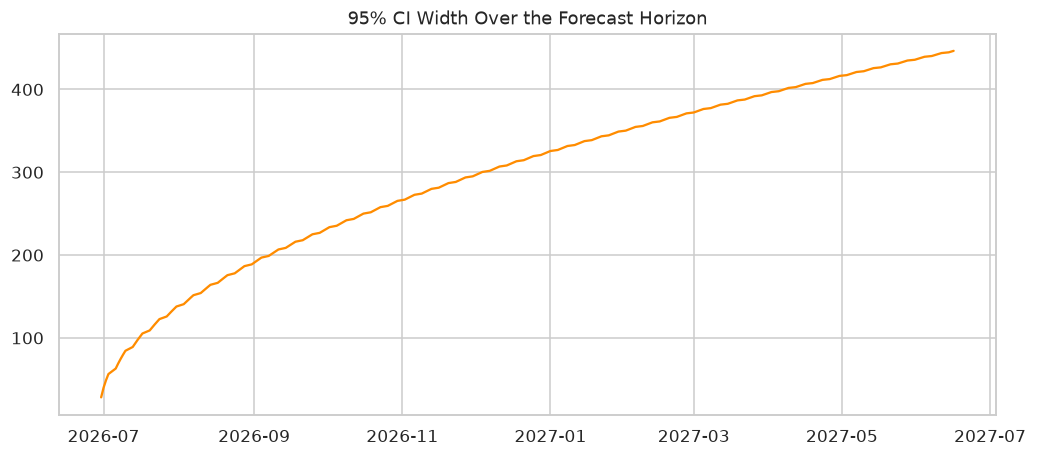

CI width day 1: 28.13  | CI width final day: 446.57


In [5]:
ci_width = fc_hi - fc_lo
fig, ax = plt.subplots(figsize=(11,4.5))
ax.plot(fc_mean.index, ci_width.values, color='darkorange')
ax.set_title('95% CI Width Over the Forecast Horizon'); plt.show()
print('CI width day 1:', round(ci_width.iloc[0],2), ' | CI width final day:', round(ci_width.iloc[-1],2))

## 3.3 Interpretation

- **Trend**: whether the point forecast is upward, downward, or flat depends on the fitted drift term of the chosen model — see the printed forecast summary above.
- **Opportunities**: an upward trend with a still-reasonable lower bound suggests room for a modest TSLA allocation.
- **Risks**: the wide and widening confidence interval highlights how unreliable point forecasts become at longer horizons — position sizing should stay conservative, and this uncertainty band is fed directly into the risk-aware Task 4 optimization.